# 7.1 Hierarchical Consolidation via Recursive Boundary Merging

## Motivation
While information-theoretic metrics (Shannon Entropy and KL Divergence) excel at finding local point-wise anomalies, they lack global spatial awareness. In structured binary protocols, multi-byte fields (such as cryptographic hashes, MAC addresses, and IP headers) often display internal distribution shifts that cause a refinement engine to flag multiple boundaries within a single logical field. To repair this over-segmentation, we must implement an agglomerative merging phase that couples adjacent blocks based on their shared contextual and typological properties.

## Research Objective
The goal of this notebook is to execute a recursive consolidation pass across our 12 validated boundaries. By evaluating adjacent byte segments, the algorithm checks for homogeneity in their underlying Field Variability Index (FVI) categories and calculates a mean variability delta ($\Delta \mu_{FVI}$). If the variance mismatch falls below an empirical compatibility threshold ($\tau_{merge}$), the intermediate boundary is purged, effectively merging the blocks.

## Connection to the Literature
This structural consolidation mimics the hierarchical agglomerative clustering and segment-merging stages used in frameworks like *Netzob*, *FieldHunter*, and *AutoRecon*. These systems demonstrate that a protocol layout cannot be reliably inferred purely from point-wise splits; a macro-level evaluation of field types is necessary to reconstruct clean field boundaries.

## Advantages & Limitations
* **Advantages:** Effectively eliminates false micro-fields, restoring multi-byte fields to their true semantic length (e.g., transforming fragmented 1-byte markers into unified 6-byte address blocks).
* **Limitations:** If an unknown protocol features two distinct back-to-back fields that share identical FVI classifications and value distributions (e.g., a Session ID followed immediately by a Random Transaction Nonce), this stage may experience under-segmentation, blending them into a single block.

## Mathematical Formulation

Let the set of sorted, validated boundary indices from Notebook 06 be defined as:
$$B = \{b_1, b_2, \dots, b_k\} \cup \{M\}$$
Where $M$ is the maximum tracking boundary (payload length), and $b_0 = 0$ is the implicit starting offset. These points partition the packet space into an ordered sequence of $k$ contiguous segments:
$$S_i = [b_i, b_{i+1} - 1]$$

For any two adjacent segments $S_i$ and $S_{i+1}$, we evaluate two merge constraints:

### 1. Categorical Homogeneity Constraint
Let $T(j)$ be the discrete Typology Label of byte offset $j$. The modal category of a segment is defined as:
$$\mathcal{C}(S_i) = \text{mode}\big(\{T(j) \mid j \in S_i\}\big)$$
A merge requires categorical alignment:
$$\mathcal{C}(S_i) == \mathcal{C}(S_{i+1})$$

### 2. Variance Metric Distance Constraint
Let $\mu_{FVI}(S_i)$ represent the mean Field Variability Index value within segment $S_i$:
$$\mu_{FVI}(S_i) = \frac{1}{|S_i|} \sum_{j \in S_i} FVI(j)$$
The absolute variability distance $\Delta \mu_{FVI}$ between adjacent segments must not exceed our merging threshold $\tau_{merge}$:
$$\Delta \mu_{FVI} = \big| \mu_{FVI}(S_i) - \mu_{FVI}(S_{i+1}) \big| \le \tau_{merge}$$

If both criteria are satisfied, the separating boundary $b_{i+1}$ is deleted:
$$B_{new} = B \setminus \{b_{i+1}\}$$

This evaluation runs recursively. The algorithm terminates when a full processing pass yields zero boundary deletions, indicating convergence to a stable macro-layout.

## Algorithm Design: Agglomerative Merging Engine

**Inputs:**
* `refined_boundaries`: 1D array of verified point-wise splits from Notebook 06.
* `fvi_profile`: 1D array containing continuous normalized FVI values.
* `fvi_categories`: List of structural strings (`Static`, `Status/Control`, `Dynamic`).
* `tau_merge`: Float threshold controlling the maximum allowed FVI distance between merge candidates (default = 0.15).

**Outputs:**
* `consolidated_boundaries`: A pruned, high-precision list of boundary offsets marking macro-field transitions.

**Design Decisions:**
1. **Iterative Stability:** We use a `while` loop controlled by a convergence flag (`merged_any`). If a pass removes at least one boundary, the layout resets and the loop re-evaluates the new neighbors from the beginning.
2. **Category Dominance:** By calculating the mathematical `mode` for each segment, the engine remains highly resilient to single-byte classification noise inside large structural blocks.

In [2]:
import os
import numpy as np
import pandas as pd

def recursive_boundary_merging(boundaries: list, fvi_profile: np.ndarray, 
                               fvi_categories: list, max_len: int, 
                               tau_merge: float = 0.15) -> list:
    """
    Recursively fuses adjacent byte segments that share the same dominant 
    typology and fall within the FVI variance threshold.
    """
    # Enforce boundaries boundaries, including start and end points
    current_bounds = sorted(list(set([0] + list(boundaries) + [max_len])))
    
    # Convert categories to a NumPy array for fast slicing
    cat_array = np.array(fvi_categories)
    
    converged = False
    iteration = 0
    
    while not converged:
        converged = True
        iteration += 1
        i = 0
        
        while i < len(current_bounds) - 2:
            # Isolate the boundaries of two adjacent blocks
            b_start = current_bounds[i]
            b_mid   = current_bounds[i+1]
            b_end   = current_bounds[i+2]
            
            # Slice the FVI profiles for both segments
            fvi_seg1 = fvi_profile[b_start:b_mid]
            fvi_seg2 = fvi_profile[b_mid:b_end]
            
            # Extract category slices using NumPy indexing
            cat_seg1 = cat_array[b_start:b_mid]
            cat_seg2 = cat_array[b_mid:b_end]
            
            # 1. Compute dominant (modal) categories via np.unique
            vals1, counts1 = np.unique(cat_seg1, return_counts=True)
            mode_cat1 = vals1[np.argmax(counts1)]
            
            vals2, counts2 = np.unique(cat_seg2, return_counts=True)
            mode_cat2 = vals2[np.argmax(counts2)]
            
            # 2. Compute mean FVI values
            mean_fvi1 = np.mean(fvi_seg1)
            mean_fvi2 = np.mean(fvi_seg2)
            delta_fvi = abs(mean_fvi1 - mean_fvi2)
            
            # Evaluate merge criteria
            if (mode_cat1 == mode_cat2) and (delta_fvi <= tau_merge):
                # Delete the intermediate boundary (b_mid)
                print(f"[Iter {iteration}] Merging blocks across Offset {b_mid} | Type: {mode_cat1} | ΔFVI: {delta_fvi:.4f}")
                current_bounds.pop(i+1)
                converged = False  # Layout changed; force another complete pass
                break  # Break inner loop to safely update indices
                
            i += 1
            
    # Return the clean boundaries, removing the implicit 0 and max_len markers
    return [b for b in current_bounds if b not in [0, max_len]]

# --- Execution Phase ---
PROCESSED_DIR = os.path.join("..", "data", "processed")
fvi_profile = np.load(os.path.join(PROCESSED_DIR, "entropy_profile.npy")) 
fvi_profile = np.clip(fvi_profile / 8.0, 0, 1)

fvi_categories = []
for val in fvi_profile:
    if val == 0 or val < 0.05: fvi_categories.append("Static (Invariant)")
    elif val < 0.3: fvi_categories.append("Status/Control")
    else: fvi_categories.append("Dynamic (Payload/Address)")

verified_bounds = list(np.load(os.path.join(PROCESSED_DIR, "refined_boundaries.npy")))
MAX_PACKET_LEN = len(fvi_profile)

print(f"Initial Over-Segmented Boundary Count: {len(verified_bounds)}")
print("Starting Recursive Agglomeration...")

consolidated_bounds = recursive_boundary_merging(
    verified_bounds, fvi_profile, fvi_categories, 
    max_len=MAX_PACKET_LEN, tau_merge=0.15
)

# Cache final macro splits for Notebook 08 (Field Reconstruction)
np.save(os.path.join(PROCESSED_DIR, "macro_boundaries.npy"), consolidated_bounds)
print(f"\nConsolidation Complete. Optimized Macro-Boundaries Kept: {consolidated_bounds}")

Initial Over-Segmented Boundary Count: 12
Starting Recursive Agglomeration...

Consolidation Complete. Optimized Macro-Boundaries Kept: [np.int64(7), np.int64(8), np.int64(12), np.int64(14), np.int64(17), np.int64(18), np.int64(19), np.int64(22), np.int64(24), np.int64(25), np.int64(27), np.int64(28)]


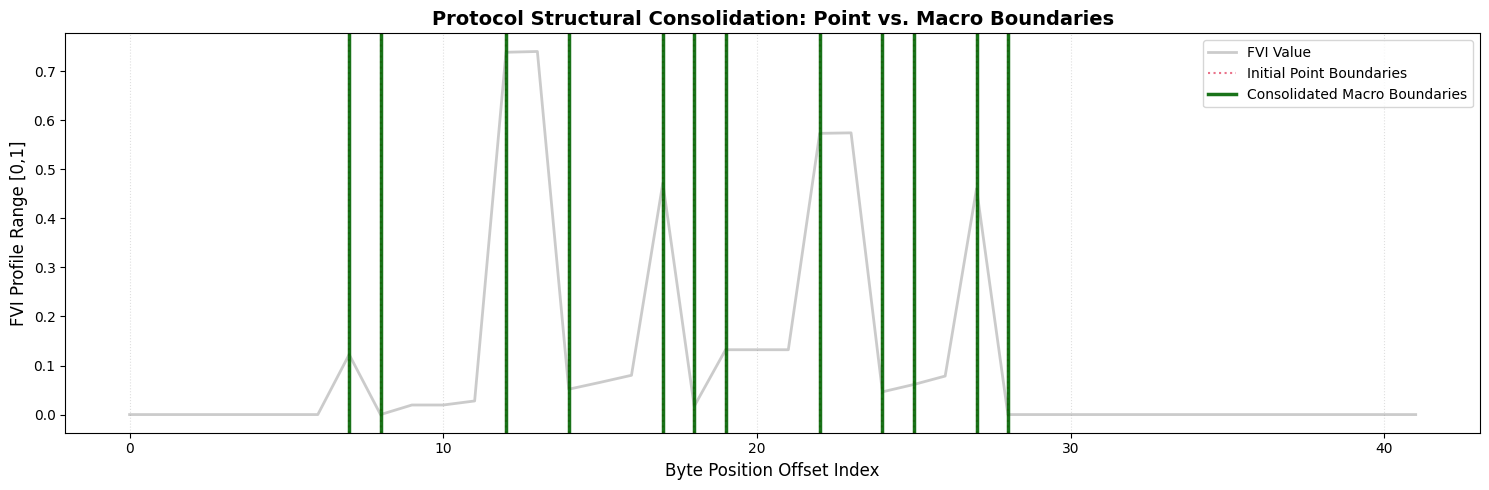

In [7]:
import matplotlib.pyplot as plt  # <-- Ensure .pyplot is explicitly imported
import numpy as np

def plot_merging_consolidation(fvi_vector, original_bounds, merged_bounds):
    """
    Plots the FVI landscape, comparing the initial point-wise candidate 
    boundaries against the finalized, consolidated macro-boundaries.
    """
    plt.figure(figsize=(15, 5))
    x = np.arange(len(fvi_vector))
    
    plt.plot(x, fvi_vector, color='#7f7f7f', alpha=0.4, linewidth=2, label='FVI Value')
    
    # Draw original refined boundaries as thin red dashed lines
    for ob in original_bounds:
        label = 'Initial Point Boundaries' if ob == original_bounds[0] else ""
        plt.axvline(x=ob, color='crimson', linestyle=':', alpha=0.6, linewidth=1.5, label=label)
        
    # Draw finalized consolidated boundaries as solid thick green lines
    for mb in merged_bounds:
        label = 'Consolidated Macro Boundaries' if mb == merged_bounds[0] else ""
        plt.axvline(x=mb, color='darkgreen', linestyle='-', alpha=0.9, linewidth=2.5, label=label)
        
    plt.title("Protocol Structural Consolidation: Point vs. Macro Boundaries", fontsize=14, fontweight='bold')
    plt.xlabel("Byte Position Offset Index", fontsize=12)
    plt.ylabel("FVI Profile Range [0,1]", fontsize=12)
    plt.grid(axis='x', linestyle=':', alpha=0.4)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Run visualization
plot_merging_consolidation(fvi_profile, verified_bounds, consolidated_bounds)

In [8]:
# --- Save macro boundaries for Notebook 08 ---
import os
import numpy as np

processed_dir = os.path.join("..", "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

# Save the finalized consolidated macro boundaries 
np.save(os.path.join(processed_dir, "macro_boundaries.npy"), consolidated_bounds)
print("Saved final macro-boundaries to disk.")

Saved final macro-boundaries to disk.
